# Analysis for Slides - Store Segmentation
**Presenter: Emine Betül Argin**

In this section

In [27]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Setting path
path = r'../data/'

# 2. Loading the files
sales = pd.read_csv(path + 'sales.csv')
stores = pd.read_csv(path + 'stores.csv')
products = pd.read_csv(path + 'products.csv')

# 3. UNIFICATION: Merging everything into one Master Table
# We link sales to stores, then link that result to products
master_df = pd.merge(sales, stores, on='Store_ID')
master_df = pd.merge(master_df, products, on='Product_ID')

# Show the first few rows of your unified table
master_df.head()

,Sale_ID,Date,Store_ID,Product_ID,Units,Store_Name,Store_City,Store_Location,Store_Open_Date,Product_Name,Product_Category,Product_Cost,Product_Price
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,$9.99,$12.99
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,$9.99,$15.99
2,3,2022-01-01,6,8,1,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,Games,$3.99,$6.99
3,4,2022-01-01,48,7,1,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23,Dart Gun,Sports & Outdoors,$11.99,$15.99
4,5,2022-01-01,44,18,1,Maven Toys Puebla 3,Puebla,Residential,2014-12-27,Lego Bricks,Toys,$34.99,$39.99


In [28]:
# 1. Clean the Price column: Remove '$' and turn it into a Number (float)
products['Product_Price'] = products['Product_Price'].str.replace('$', '').str.strip().astype(float)

# 2. Now the UNIFICATION
master_df = pd.merge(sales, stores, on='Store_ID')
master_df = pd.merge(master_df, products, on='Product_ID')

# 3. Create the summary (This time the Mean will actually work!)
store_summary = master_df.groupby('Store_Name').agg({
    'Units': 'sum',
    'Product_Price': 'mean'
}).reset_index()

store_summary.columns = ['Store_Name', 'Total_Units', 'Avg_Price']

print(store_summary.isnull().sum())

Store_Name     0
Total_Units    0
Avg_Price      0
dtype: int64


In [29]:
# --- STEP 1: Standardizing ---
scaler = StandardScaler()
# Now that Avg_Price is a number, scaler will work!
scaled_features = scaler.fit_transform(store_summary[['Total_Units', 'Avg_Price']])

# --- STEP 2: Running K-Means ---
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
store_summary['Cluster'] = kmeans.fit_predict(scaled_features)

# --- STEP 3: The Result ---
print("\nSuccess! Here are your store clusters:")
store_summary.head(10)


Success! Here are your store clusters:


,Store_Name,Total_Units,Avg_Price,Cluster
0,Maven Toys Aguascalientes 1,17865,13.664801,1
1,Maven Toys Campeche 1,24556,13.094493,1
2,Maven Toys Campeche 2,16277,13.315732,1
3,Maven Toys Chetumal 1,18965,13.938921,0
4,Maven Toys Chihuahua 1,18070,14.413846,0
5,Maven Toys Chihuahua 2,22326,12.717081,1
6,Maven Toys Chilpancingo 1,18327,13.621922,1
7,Maven Toys Ciudad Victoria 1,20501,14.685959,0
8,Maven Toys Ciudad de Mexico 1,33479,13.780867,2
9,Maven Toys Ciudad de Mexico 2,42757,13.525143,2


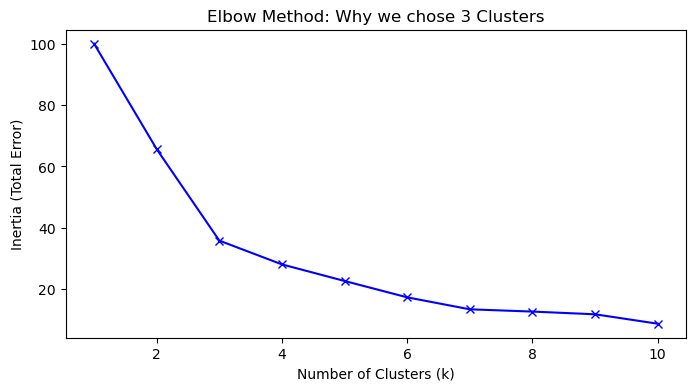

In [30]:
# --- BETÜL'S PART: JUSTIFICATION ---
import matplotlib.pyplot as plt

inertia = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Total Error)')
plt.title('Elbow Method: Why we chose 3 Clusters')
plt.show()

In [31]:
# --- BETÜL'S PART: BUSINESS PROFILES ---
# We calculate the average performance for each group
profiles = store_summary.groupby('Cluster').agg({
    'Total_Units': 'mean',
    'Avg_Price': 'mean',
    'Store_Name': 'count'
}).rename(columns={'Store_Name': 'Count_of_Stores'})

print("Summary of Store Types in Mexico:")
print(profiles)

Summary of Store Types in Mexico:
          Total_Units  Avg_Price  Count_of_Stores
Cluster                                          
0        20674.157895  14.391465               19
1        20091.640000  13.280466               25
2        32577.500000  13.774271                6


In [32]:
# Code for Slide VII/XII: Cluster Interpretation
cluster_profiles = store_summary.groupby('Cluster').agg({
    'Total_Units': ['mean', 'min', 'max'],
    'Avg_Price': 'mean',
    'Store_Name': 'count'
}).reset_index()

print("--- Business Profiles for each Store Segment ---")
print(cluster_profiles)

--- Business Profiles for each Store Segment ---
  Cluster   Total_Units                Avg_Price Store_Name
                   mean    min    max       mean      count
0       0  20674.157895  15964  25296  14.391465         19
1       1  20091.640000  16217  24740  13.280466         25
2       2  32577.500000  26634  42757  13.774271          6


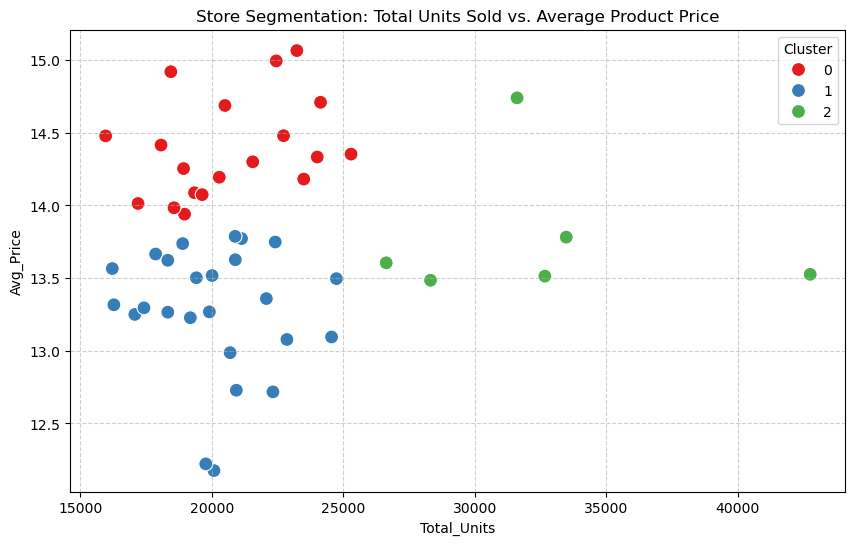

In [33]:
# Code for Slide VII: Visualizing the Findings
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=store_summary, x='Total_Units', y='Avg_Price', hue='Cluster', palette='Set1', s=100)
plt.title('Store Segmentation: Total Units Sold vs. Average Product Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()